In [6]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os
import sys

parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# MPC import
import numpy as np
from LinearMPC_regulation.MPCVelControl import MPCVelControl
from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [8]:
Ts = 0.05
sim_time = 10.0
H = 2.0
x0 = np.zeros(12)
x0[6] = 5.0 # vx
x0[7] = 5.0 # vy
x0[8] = 5.0 # vz
x0[5] = 30 * np.pi / 180 # gamma

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H)

t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, _ = rocket.simulate_control(
    mpc, sim_time, H, x0, method="linear"
)

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:, :-1], u_cl, T_ol=t_ol[..., :-1], X_ol=x_ol, U_ol=u_ol);

/home/ilyas/miniconda3/envs/mpc2025/lib/python3.12/site-packages/mpt4py/base.py:182: RuntimeWarning: invalid value encountered in divide
  H_normalized = H / np.linalg.norm(H, axis=1).reshape((-1,1))


Simulating time 0.00: 

/home/ilyas/miniconda3/envs/mpc2025/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.30: 
Simulating time 0.35: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.40: 
Simulating time 0.45: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.50: 
Simulating time 0.55: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.60: 
Simulating time 0.65: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.70: 
Simulating time 0.75: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.80: 
Simulating time 0.85: 
 State beta violation: -0.17 < -0.17, 
 State alpha violation: 0.17 > 0.17, 
Simulating time 0.90: 
Simulating time 0.95: 
 State beta violation: 

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=199, step=2), IntSlider(value=0…

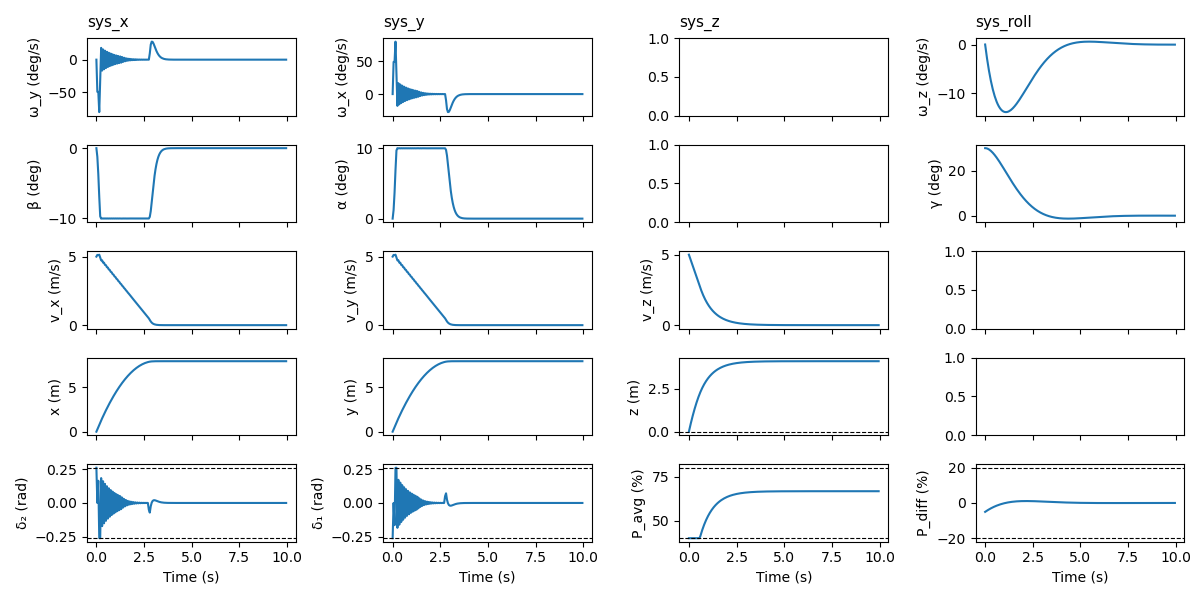

In [9]:
from src.vel_rocket_vis import plot_static_states_inputs
import matplotlib.pyplot as plt

# hack to intercept the figure
old_show = plt.show
def new_show():
    plt.savefig('del3_1_sim.png')
    old_show()

plt.show = new_show
plot_static_states_inputs(t_cl[:-1], x_cl[:, :-1], u_cl)
plt.show = old_show

/home/ilyas/miniconda3/envs/mpc2025/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/ilyas/miniconda3/envs/mpc2025/lib/python3.12/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


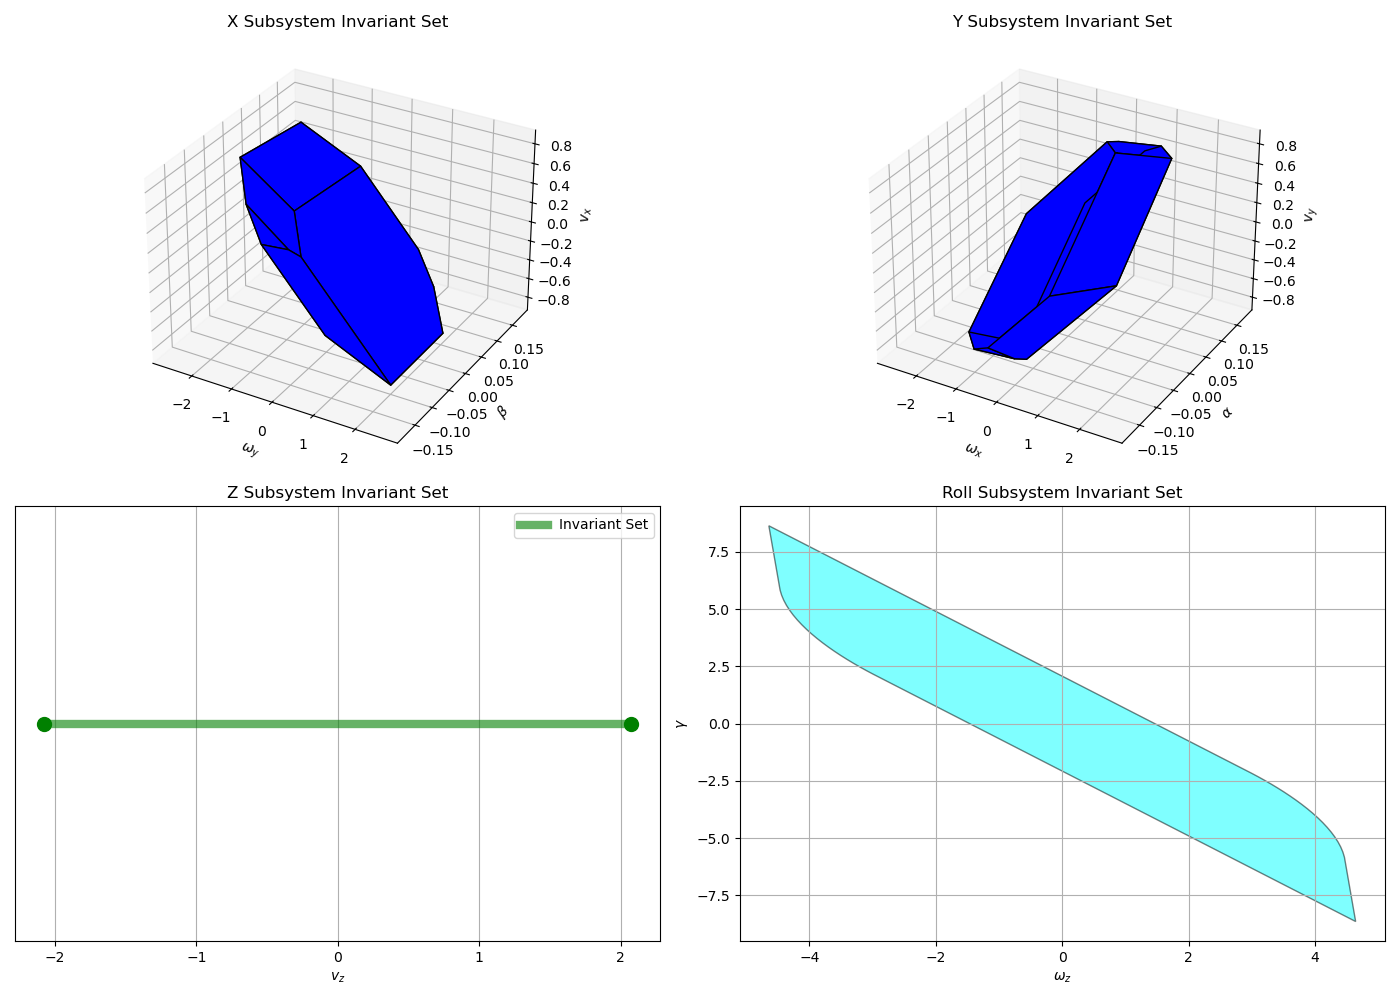

In [ ]:
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are
from mpt4py import Polyhedron
import numpy as np

# helper function to compute and plot invariant set
def plot_invariant_set(sys_name, A, B, Q, R, x_min, x_max, u_min, u_max, ax, labels=None):
    # lqr gain
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)
    
    # closed loop dynamics
    A_cl = A - B @ K
    
    # constraints in form F*x <= g
    F_list = []
    g_list = []
    
    nx = A.shape[0]
    nu = B.shape[1]
    
    # state constraints
    if x_min is not None:
        # x <= x_max
        F_list.append(np.eye(nx))
        g_list.append(x_max)
        # -x <= -x_min
        F_list.append(-np.eye(nx))
        g_list.append(-x_min)
        
    # input constraints (u = -K*x)
    # -K*x <= u_max_delta
    F_list.append(-K)
    g_list.append(u_max)
    # K*x <= -u_min
    F_list.append(K)
    g_list.append(-u_min)
    
    F = np.vstack(F_list)
    g = np.hstack(g_list)
    

    P_poly = Polyhedron.from_Hrep(F, g)
    
    # invariant set
    # algorithm: Omega_0 = P, Omega_{k+1} = Omega_k \cap {x | A_cl x \in Omega_k}
    Omega = P_poly
    max_iter = 20
    for i in range(max_iter):
        # pre-set: {x | A_cl x \in Omega}
        F_omega = Omega.A
        g_omega = Omega.b
        
        # pre-set: F_omega * (A_cl * x) <= g_omega
        F_pre = F_omega @ A_cl
        g_pre = g_omega
        
        Pre_Omega = Polyhedron.from_Hrep(F_pre, g_pre)
        
        Omega_next = Omega.intersect(Pre_Omega)
        
        try:
            if Pre_Omega.contains(Omega):
                break
        except:
            pass
        
        Omega = Omega_next
        
    O_inf = Omega
    
    if nx == 1:
        # 1D case
        vs = O_inf.V.flatten()
        min_v, max_v = np.min(vs), np.max(vs)
        ax.plot([min_v, max_v], [0, 0], 'g-', linewidth=6, alpha=0.6, label='Invariant Set')
        ax.scatter([min_v, max_v], [0, 0], color='g', s=100)
        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([])
        ax.set_xlabel(labels[0] if labels else 'x')
        ax.legend()
        ax.grid(True)
    elif nx == 3:
        # 3D case
        O_inf.plot(ax=ax) 
        ax.set_xlabel(labels[0] if labels else 'x_1')
        ax.set_ylabel(labels[1] if labels else 'x_2')
        ax.set_zlabel(labels[2] if labels else 'x_3')
    else:
        # 2D Case
        O_inf.plot(ax=ax, color='cyan', alpha=0.5)
        ax.set_xlabel(labels[0] if labels else 'x_1')
        ax.set_ylabel(labels[1] if labels else 'x_2')
        ax.grid(True)
        
    ax.set_title(f'{sys_name} Invariant Set')

# setup plots with mixed projections
fig = plt.figure(figsize=(14, 10))

# X subsystem (3D)
# state: [wy, beta, vx]
Q_x = np.diag([1.0, 10.0, 100.0])
R_x = np.array([[1.0]])
x_min_x = np.array([-100, -0.1745, -100])
x_max_x = np.array([100, 0.1745, 100])
u_min_x = np.array([-0.26])
u_max_x = np.array([0.26])

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
plot_invariant_set('X Subsystem', mpc.mpc_x.A, mpc.mpc_x.B, Q_x, R_x, x_min_x, x_max_x, u_min_x, u_max_x, ax1, labels=[r'$\omega_y$', r'$\beta$', r'$v_x$'])

# Y subsystem (3D)
# state: [wx, alpha, vy]
Q_y = np.diag([1.0, 10.0, 100.0])
R_y = np.array([[1.0]])
x_min_y = np.array([-100, -0.1745, -100])
x_max_y = np.array([100, 0.1745, 100])
u_min_y = np.array([-0.26])
u_max_y = np.array([0.26])

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
plot_invariant_set('Y Subsystem', mpc.mpc_y.A, mpc.mpc_y.B, Q_y, R_y, x_min_y, x_max_y, u_min_y, u_max_y, ax2, labels=[r'$\omega_x$', r'$\alpha$', r'$v_y$'])

# Z subsystem (1D)
# state: [vz]
Q_z = np.array([[100.0]])
R_z = np.array([[1.0]])
x_min_z = np.array([-100])
x_max_z = np.array([100])
u_min_z = np.array([-20.0])
u_max_z = np.array([20.0])

ax3 = fig.add_subplot(2, 2, 3)
plot_invariant_set('Z Subsystem', mpc.mpc_z.A, mpc.mpc_z.B, Q_z, R_z, x_min_z, x_max_z, u_min_z, u_max_z, ax3, labels=[r'$v_z$'])

# roll subsystem (2D)
# state: [wz, gamma]
Q_roll = np.diag([1.0, 100.0])
R_roll = np.array([[1.0]])
x_min_roll = np.array([-100, -100])
x_max_roll = np.array([100, 100])
u_min_roll = np.array([-20.0])
u_max_roll = np.array([20.0])

ax4 = fig.add_subplot(2, 2, 4)
plot_invariant_set('Roll Subsystem', mpc.mpc_roll.A, mpc.mpc_roll.B, Q_roll, R_roll, x_min_roll, x_max_roll, u_min_roll, u_max_roll, ax4, labels=[r'$\omega_z$', r'$\gamma$'])

plt.tight_layout()
plt.savefig('del3_1_sets.png')
# plt.show()